In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("/Users/deepanshus/StockMarketPredictor/Project/data/Combined/all/1.csv")

In [3]:
df.head()

,rsi,macd,sma_ratio,volume_change,volatility,target
0,52.729384,5.231607,1.041503,-0.764616,0.015705,-0.009905
1,54.632972,5.343971,1.040495,-0.387146,0.015875,0.033691
2,68.850806,6.284495,1.044956,3.874652,0.015084,-0.028466
3,57.588533,6.152034,1.046341,-0.729922,0.018880,-0.012892
4,53.169572,5.627148,1.046767,-0.136228,0.019619,0.000297


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[['rsi','macd','sma_ratio','volume_change','volatility']])

In [9]:
df.corr()['target'].sort_values(ascending=False)
X = df[['rsi','macd','sma_ratio','volume_change','volatility']]
y = (df['target'] > 0).astype(int) 

In [12]:
from sklearn.ensemble import RandomForestClassifier

temp_model = RandomForestClassifier()
temp_model.fit(X, y)

importances = temp_model.feature_importances_

for name, score in zip(X.columns, importances):
    print(name, score)

rsi 0.2023920033144652
macd 0.20340782736275725
sma_ratio 0.19744425449290912
volume_change 0.19728200496623574
volatility 0.19947390986363273


In [13]:
df.corr()['target'].sort_values()

macd            -0.205279
rsi             -0.140928
sma_ratio       -0.105668
volume_change    0.006657
volatility       0.049568
target           1.000000
Name: target, dtype: float64

In [14]:
df['rsi_macd'] = df['rsi'] * df['macd']

In [15]:
df[['rsi_macd','target']].corr()

,rsi_macd,target
rsi_macd,1.000000,-0.171171
target,-0.171171,1.000000


In [16]:
# Momentum + Trend
df['rsi_macd'] = df['rsi'] * df['macd']

# Trend + Structure
df['macd_sma'] = df['macd'] * df['sma_ratio']

# Momentum + Structure
df['rsi_sma'] = df['rsi'] * df['sma_ratio']

In [17]:
df['rsi_macd_sma'] = df['rsi'] * df['macd'] * df['sma_ratio']

In [18]:
df.corr()['target'].sort_values()

macd            -0.205279
macd_sma        -0.184827
rsi_macd        -0.171171
rsi_macd_sma    -0.153636
rsi_sma         -0.146863
rsi             -0.140928
sma_ratio       -0.105668
volume_change    0.006657
volatility       0.049568
target           1.000000
Name: target, dtype: float64

In [19]:
# Class-wise Analysis
df['movement'] = (df['target'] > 0).astype(int)

df.groupby('movement')[['rsi','macd','sma_ratio','volume_change','volatility']].mean()

,rsi,macd,sma_ratio,volume_change,volatility
movement,,,,,
0,52.624450,14.956797,1.016585,0.322462,0.043972
1,50.673009,5.171993,1.013683,0.338133,0.045486


In [20]:
df['rsi_zone'] = pd.cut(df['rsi'], bins=[0,30,70,100], labels=['Low','Neutral','High'])

df.groupby('rsi_zone')['movement'].mean()

/var/folders/g8/43rm_8rs5wbchfhhkxt_832c0000gn/T/ipykernel_90937/3134566199.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rsi_zone')['movement'].mean()


rsi_zone
Low        0.577971
Neutral    0.508006
High       0.477382
Name: movement, dtype: float64

In [21]:
high_macd = df[df['macd'] > df['macd'].quantile(0.9)]
low_macd  = df[df['macd'] < df['macd'].quantile(0.1)]

print("High MACD movement:", high_macd['movement'].mean())
print("Low MACD movement:", low_macd['movement'].mean())

High MACD movement: 0.4640679844818031
Low MACD movement: 0.606502863476815


<Axes: >

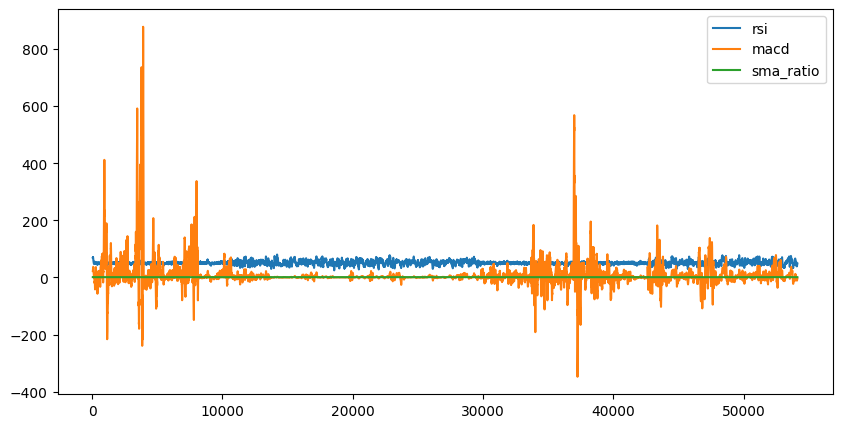

In [22]:
df[['rsi','macd','sma_ratio']].rolling(50).mean().plot(figsize=(10,5))

<Axes: title={'center': 'Feature Importance (Correlation)'}>

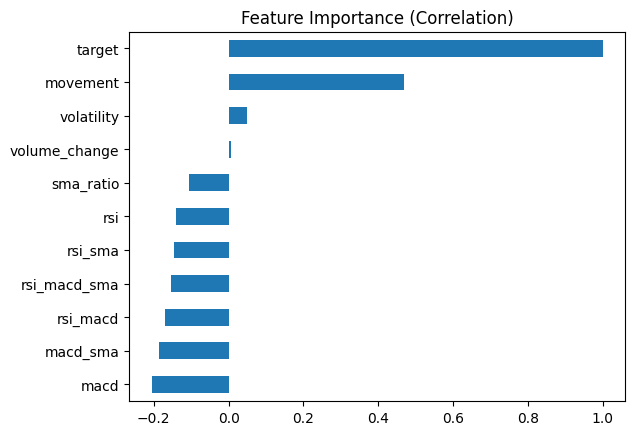

In [24]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df.corr()['target'].sort_values().plot(kind='barh', title="Feature Importance (Correlation)")